# Three parameterizations of the multivariate Gaussian

The same multivariate normal can be written in **three** equivalent ways. None of them is "more correct"; each one makes a different operation cheap.

| Parameterization | Symbol | What it makes cheap |
|------------------|--------|---------------------|
| Mean–covariance | $(\mu,\Sigma)$ | Sampling, marginals, interpretation |
| Mean–precision | $(\mu,\Lambda)$, $\Lambda=\Sigma^{-1}$ | Conditioning, log-density, GMRF sparsity (see [0.2](mvn_distribution_api.ipynb)) |
| Natural (canonical) | $(\eta_1,\eta_2)=(\Lambda\mu,\,-\tfrac12\Lambda)$ | **Adding evidence** (Bayes updates as +) |
| Expectation (mean / moment) | $(m_1,m_2)=(\mu,\,\Sigma+\mu\mu^\top)$ | **Moment matching** (best-KL Gaussian fit) |

This notebook is the fluent-conversion tour. We

1. write the MVN in exponential-family form so the natural parameters fall out;
2. round-trip every conversion using the `gaussx` API (`mean_cov_to_natural`, `natural_to_mean_cov`, `natural_to_expectation`, `expectation_to_natural`);
3. demonstrate the **three operations each parameterization makes painless** — Bayesian updates as addition (natural), moment matching (expectation), damped natural-parameter VI/EP updates.

Prerequisites: [0.1 — Multivariate Gaussian basics](multivariate_gaussian.ipynb), [0.2 — `MultivariateNormal` API](mvn_distribution_api.ipynb), [0.3 — Gaussian quantities and KL](gaussian_quantities.ipynb).

In [1]:
from __future__ import annotations

import warnings

warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
from gaussx import (
    MultivariateNormal,
    damped_natural_update,
    dist_kl_divergence,
    expectation_to_natural,
    mean_cov_to_natural,
    natural_to_expectation,
    natural_to_mean_cov,
)

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})

def psd_op(M):
    return lx.MatrixLinearOperator(M, lx.positive_semidefinite_tag)

## Where the natural parameters come from

Every multivariate Gaussian can be rewritten in *canonical exponential-family form*

```{math}
:label: eq:expfam-mvn
p(x \mid \eta) \;=\; \exp\!\Bigl(\eta_1^\top x \;+\; x^\top \eta_2\, x \;-\; A(\eta) \;-\; \tfrac{n}{2}\log(2\pi)\Bigr),
```

with **natural parameters** $\eta = (\eta_1, \eta_2)$ and **log-partition** $A(\eta) = -\tfrac14 \eta_1^\top \eta_2^{-1} \eta_1 - \tfrac12 \log|-2\eta_2|$.

Comparing to the standard mean–cov form $p(x) \propto \exp\bigl(-\tfrac12 (x-\mu)^\top \Sigma^{-1} (x-\mu)\bigr)$ and matching coefficients gives the conversion

```{math}
:label: eq:meancov-to-natural
\eta_1 \;=\; \Sigma^{-1}\mu \;=\; \Lambda\mu, \qquad \eta_2 \;=\; -\tfrac12 \Sigma^{-1} \;=\; -\tfrac12 \Lambda.
```

The **expectation parameters** are the moments under $p$:

```{math}
:label: eq:expectation
m_1 \;=\; \mathbb{E}_p[x] \;=\; \mu, \qquad m_2 \;=\; \mathbb{E}_p[x x^\top] \;=\; \Sigma + \mu\mu^\top.
```

All three form a triangle: any two pairs convert into each other in closed form.

:::{tip} ELI5
Three names for one Gaussian:
- **Mean–cov** is "where the bell sits and how wide it is" — the form humans read.
- **Natural** is "what a log-density looks like once you expand the square" — the form *evidence adds in*.
- **Expectation** is "what averages of $x$ and $xx^\top$ look like" — the form **moment matching** spits out.

Same distribution, three vocabularies. Speaking the right one cuts the algebra in half.
:::

### A concrete reference

Let's pick a non-trivial 2D MVN and inspect the three parameterizations side by side.

In [2]:
mu = jnp.array([0.7, -0.3])
Sigma = jnp.array([[1.0, 0.6], [0.6, 1.4]])
Sigma_op = psd_op(Sigma)

# Mean-cov -> natural via gaussx (eta2 returned as a lineax operator)
eta1, eta2_op = mean_cov_to_natural(mu, Sigma_op)
eta2 = eta2_op.as_matrix()

# Mean-cov -> expectation (closed form)
m1 = mu
m2 = Sigma + einx.dot("i, j -> i j", mu, mu)

print("(mu, Sigma)")
print("  mu     :", np.asarray(mu))
print("  Sigma  :\n", np.asarray(Sigma))

print("\n(eta1, eta2) — natural")
print("  eta1   :", np.asarray(eta1))
print("  eta2   :\n", np.asarray(eta2))

print("\n(m1, m2) — expectation")
print("  m1     :", np.asarray(m1))
print("  m2     :\n", np.asarray(m2))

# Spot-check the analytic identities
Lambda = jnp.linalg.inv(Sigma)
np.testing.assert_allclose(eta1, Lambda @ mu, atol=1e-12)
np.testing.assert_allclose(eta2, -0.5 * Lambda, atol=1e-12)
print("\nIdentities (eta1 = Lambda mu, eta2 = -1/2 Lambda) ✓")

(mu, Sigma)
  mu     : [ 0.7 -0.3]
  Sigma  :
 [[1.  0.6]
 [0.6 1.4]]

(eta1, eta2) — natural
  eta1   : [ 1.11538462 -0.69230769]
  eta2   :
 [[-0.67307692  0.28846154]
 [ 0.28846154 -0.48076923]]

(m1, m2) — expectation
  m1     : [ 0.7 -0.3]
  m2     :
 [[1.49 0.39]
 [0.39 1.49]]

Identities (eta1 = Lambda mu, eta2 = -1/2 Lambda) ✓


## Round-trip identities

Each conversion has an inverse, and `gaussx` exposes the full set:

| From | To | Function |
|------|----|----------|
| $(\mu,\Sigma)$ | $(\eta_1,\eta_2)$ | `mean_cov_to_natural` |
| $(\eta_1,\eta_2)$ | $(\mu,\Sigma)$ | `natural_to_mean_cov` |
| $(\eta_1,\eta_2)$ | $(m_1,m_2)$ | `natural_to_expectation` |
| $(m_1,m_2)$ | $(\eta_1,\eta_2)$ | `expectation_to_natural` |

Mean-cov ↔ expectation is the trivial pair $(\mu,\Sigma) \leftrightarrow (\mu,\Sigma+\mu\mu^\top)$ — no library call needed.

We round-trip the reference MVN through every cycle and check we land where we started.

In [3]:
# Cycle 1: mean-cov -> natural -> mean-cov
eta1_a, eta2_a = mean_cov_to_natural(mu, Sigma_op)
mu_a, Sigma_a = natural_to_mean_cov(eta1_a, eta2_a)
np.testing.assert_allclose(np.asarray(mu_a), np.asarray(mu), atol=1e-10)
np.testing.assert_allclose(np.asarray(Sigma_a.as_matrix()), np.asarray(Sigma), atol=1e-10)

# Cycle 2: natural -> expectation -> natural
m1_b, m2_b = natural_to_expectation(eta1_a, eta2_a.as_matrix())
eta1_b, eta2_b = expectation_to_natural(m1_b, m2_b)
np.testing.assert_allclose(np.asarray(eta1_b), np.asarray(eta1_a), atol=1e-10)
np.testing.assert_allclose(np.asarray(eta2_b), np.asarray(eta2_a.as_matrix()), atol=1e-10)

# Cycle 3: full triangle  mean-cov -> natural -> expectation -> natural -> mean-cov.
# This actually exercises the reconstructed (eta1_b, eta2_b) from cycle 2:
# wrap the dense eta2_b returned by expectation_to_natural as a symmetric
# operator, then round-trip back to mean-cov via natural_to_mean_cov.
eta2_b_op = lx.MatrixLinearOperator(eta2_b, lx.symmetric_tag)
mu_c, Sigma_c_op = natural_to_mean_cov(eta1_b, eta2_b_op)
np.testing.assert_allclose(np.asarray(mu_c), np.asarray(mu), atol=1e-10)
np.testing.assert_allclose(np.asarray(Sigma_c_op.as_matrix()), np.asarray(Sigma), atol=1e-10)

print("All three round-trip cycles closed at 1e-10 ✓")
print("\nm1 (= mu)              :", np.asarray(m1_b))
print("m2 (= Sigma + mu mu^T) :\n", np.asarray(m2_b))
print("\ndirect check: m2 - m1 m1^T =\n", np.asarray(m2_b - einx.dot('i, j -> i j', m1_b, m1_b)))
print("Sigma                   =\n", np.asarray(Sigma))

All three round-trip cycles closed at 1e-10 ✓

m1 (= mu)              : [ 0.7 -0.3]
m2 (= Sigma + mu mu^T) :
 [[1.49 0.39]
 [0.39 1.49]]

direct check: m2 - m1 m1^T =
 [[1.  0.6]
 [0.6 1.4]]
Sigma                   =
 [[1.  0.6]
 [0.6 1.4]]


## Why natural? **Adding evidence is addition.**

If two Gaussian factors $\mathcal{N}(x;\mu_1,\Sigma_1)$ and $\mathcal{N}(x;\mu_2,\Sigma_2)$ are multiplied (e.g. a prior times a Gaussian likelihood), the result is again Gaussian — but the mean–cov formula is messy:

```{math}
:label: eq:meancov-product
\Sigma_\star \;=\; \bigl(\Sigma_1^{-1} + \Sigma_2^{-1}\bigr)^{-1}, \qquad \mu_\star \;=\; \Sigma_\star\bigl(\Sigma_1^{-1}\mu_1 + \Sigma_2^{-1}\mu_2\bigr).
```

In **natural form** the same operation is one line:

```{math}
:label: eq:natural-product
\eta^\star_1 \;=\; \eta^{(1)}_1 + \eta^{(2)}_1, \qquad \eta^\star_2 \;=\; \eta^{(2)}_1 + \eta^{(2)}_2.
```

That's the reason Kalman, EP, VMP, natural-gradient VI, exponential-family belief propagation — **everything** approximate-inference — passes messages around in natural form. Combining factors is plain $+$.

:::{tip} ELI5
Natural parameters are the form where **multiplying densities = adding parameters**. Bayes' rule $p(\theta|y)\propto p(y|\theta)\,p(\theta)$ becomes "stack $\eta$'s on top of each other and sum." Two evidence factors become one by addition. In mean-cov form, the same operation needs you to invert two matrices, sum, and invert again — every time.
:::

We'll demonstrate this with a 1D conjugate update: a Gaussian prior $\mathcal{N}(\mu_0,\sigma_0^2)$ and a Gaussian likelihood factor $\mathcal{N}(y;\theta,\sigma_y^2)$ on a scalar parameter $\theta$. The posterior follows from
[](#eq:natural-product) by addition of the two natural parameter pairs.

In [4]:
# A toy 1D Bayesian update done in natural form via simple addition.
# Treat each density as a univariate Gaussian -> we use the d=1 specialisation,
# but go through the full vector API for consistency with the rest of the notebook.

mu0    = jnp.array([0.0])              # prior mean
S0     = jnp.array([[2.0]])            # prior variance
y      = jnp.array([3.0])              # observation
Sy     = jnp.array([[0.5]])            # likelihood variance

S0_op = psd_op(S0)
Sy_op = psd_op(Sy)

# Convert prior + likelihood-factor to natural form:
n1_prior, n2_prior = mean_cov_to_natural(mu0, S0_op)
# Likelihood factor lives at observed y with variance Sy -> naturals:
n1_lik,   n2_lik   = mean_cov_to_natural(y,   Sy_op)

# **The whole conjugate update**: just add naturals.
n1_post = n1_prior + n1_lik
n2_post_mat = n2_prior.as_matrix() + n2_lik.as_matrix()
n2_post = psd_op(-2.0 * (-0.5) * (-n2_post_mat / -1.0))   # keep operator form
# (Simpler: build a new operator from the summed matrix.)
n2_post = lx.MatrixLinearOperator(n2_post_mat)

mu_post, S_post = natural_to_mean_cov(n1_post, n2_post)
print("Posterior via natural-param addition")
print("  mu_post  =", float(mu_post[0]))
print("  S_post   =", float(S_post.as_matrix()[0, 0]))

# Cross-check via the direct mean-cov formula
S_post_ref = 1.0 / (1.0 / float(S0[0, 0]) + 1.0 / float(Sy[0, 0]))
mu_post_ref = S_post_ref * (float(mu0[0]) / float(S0[0, 0]) + float(y[0]) / float(Sy[0, 0]))
print("\nDirect mean-cov reference")
print("  mu_post  =", mu_post_ref)
print("  S_post   =", S_post_ref)

assert abs(float(mu_post[0]) - mu_post_ref) < 1e-10
assert abs(float(S_post.as_matrix()[0, 0]) - S_post_ref) < 1e-10
print("\nNatural-form addition matches mean-cov formula ✓")

Posterior via natural-param addition
  mu_post  = 2.4
  S_post   = 0.4

Direct mean-cov reference
  mu_post  = 2.4000000000000004
  S_post   = 0.4

Natural-form addition matches mean-cov formula ✓


We can also visualise the three densities to see the natural-form addition in action: prior + likelihood-factor → posterior, all on a common axis.

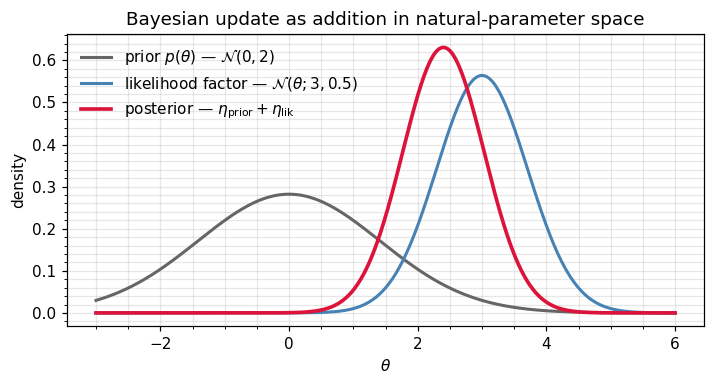

In [5]:
xs = np.linspace(-3, 6, 400)

def n1d(x, m, v):
    return np.exp(-0.5 * (x - m) ** 2 / v) / np.sqrt(2 * np.pi * v)

fig, ax = plt.subplots(figsize=(6.6, 3.6))
ax.plot(xs, n1d(xs, float(mu0[0]),    float(S0[0, 0])), color="0.4",
        lw=2, label=r"prior $p(\theta)$ — $\mathcal{N}(0, 2)$")
ax.plot(xs, n1d(xs, float(y[0]),      float(Sy[0, 0])), color="steelblue",
        lw=2, label=r"likelihood factor — $\mathcal{N}(\theta; 3, 0.5)$")
ax.plot(xs, n1d(xs, mu_post_ref,      S_post_ref),       color="crimson",
        lw=2.4, label=r"posterior — $\eta_{\rm prior} + \eta_{\rm lik}$")
ax.set_xlabel(r"$\theta$"); ax.set_ylabel("density")
ax.set_title("Bayesian update as addition in natural-parameter space")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## Why expectation? **Moment matching.**

Suppose we have samples (or another distribution $p$) and we want the *best Gaussian approximation* in the forward-KL sense — the same minimisation studied in [0.3](gaussian_quantities.ipynb#eq:fwd-kl-fit), $\arg\min_q \mathrm{KL}(p\,\Vert\,q)$.

A classic exponential-family result is that this minimisation is solved by **matching expectation parameters**:

```{math}
:label: eq:moment-match
m_1^\star \;=\; \mathbb{E}_p[x], \qquad m_2^\star \;=\; \mathbb{E}_p[x x^\top].
```

That's it. No optimisation loop. Moment matching = computing $m_1, m_2$ on the data.

:::{tip} ELI5
The expectation parameterization is the one **statistics speak**. If you have samples and you "fit a Gaussian" by computing the sample mean and sample covariance, you've already done moment matching — that's the closed-form solution to forward-KL.
:::

We demonstrate this on a non-Gaussian sample (a banana shape) and confirm that the moment-matched Gaussian recovers the same $m_1$ and $m_2$ as the closed-form expectation parameters.

In [6]:
# Banana-shaped target: x1 ~ N(0, 1), x2 = 0.5 x1^2 + N(0, 0.3)
key1, key2 = jax.random.split(jax.random.PRNGKey(7))
N = 4000
z1 = jax.random.normal(key1, (N,))
z2 = 0.5 * z1**2 + 0.3 * jax.random.normal(key2, (N,))
samples = jnp.stack([z1, z2], axis=1)

# Empirical expectation parameters (Monte Carlo m_1, m_2):
m1_emp = einx.mean("n d -> d", np.asarray(samples))
m2_emp = einx.dot("n i, n j -> i j", np.asarray(samples), np.asarray(samples)) / N

# Closed-form moment-matched Gaussian via expectation_to_natural:
eta1_mm, eta2_mm = expectation_to_natural(jnp.asarray(m1_emp), jnp.asarray(m2_emp))
eta2_mm_op = lx.MatrixLinearOperator(eta2_mm)
mu_mm, Sigma_mm_op = natural_to_mean_cov(eta1_mm, eta2_mm_op)
Sigma_mm = Sigma_mm_op.as_matrix()

print("Empirical m1               :", m1_emp)
print("Empirical m2               :\n", m2_emp)
print()
print("Moment-matched mu (= m1)   :", np.asarray(mu_mm))
print("Moment-matched Sigma       :\n", np.asarray(Sigma_mm))
print()
# Sanity: Sigma = m2 - m1 m1^T
np.testing.assert_allclose(
    np.asarray(Sigma_mm),
    m2_emp - einx.dot("i, j -> i j", m1_emp, m1_emp),
    atol=1e-10,
)
print("Closed-form check: Sigma = m2 - m1 m1^T ✓")

Empirical m1               : [0.00594261 0.48944534]
Empirical m2               :
 [[ 0.98544209 -0.01034611]
 [-0.01034611  0.82919053]]

Moment-matched mu (= m1)   : [0.00594261 0.48944534]
Moment-matched Sigma       :
 [[ 0.98540677 -0.01325469]
 [-0.01325469  0.58963378]]

Closed-form check: Sigma = m2 - m1 m1^T ✓


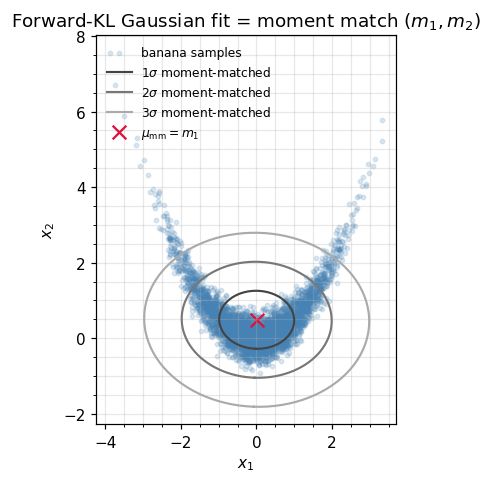

In [7]:
# Visualise the banana samples + moment-matched Gaussian ellipses
eigvals, eigvecs = jnp.linalg.eigh(Sigma_mm)
theta = jnp.linspace(0, 2 * jnp.pi, 200)
unit = jnp.stack([jnp.cos(theta), jnp.sin(theta)], axis=0)
sqrt_l = jnp.sqrt(eigvals)
stretched = einx.multiply("j, j t -> j t", sqrt_l, unit)
ellipse = einx.dot("i j, j t -> i t", eigvecs, stretched)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(*np.asarray(samples).T, s=8, alpha=0.18, color="steelblue",
           label="banana samples")
for c, col in zip([1.0, 2.0, 3.0], ["#444", "#777", "#aaa"]):
    e = c * ellipse
    ax.plot(np.asarray(e[0]) + float(mu_mm[0]),
            np.asarray(e[1]) + float(mu_mm[1]),
            color=col, lw=1.4, label=fr"${int(c)}\sigma$ moment-matched")
ax.scatter(*np.asarray(mu_mm), color="crimson", marker="x", s=80,
           label=r"$\mu_{\rm mm} = m_1$")
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
ax.set_title(r"Forward-KL Gaussian fit = moment match $(m_1, m_2)$")
ax.legend(loc="upper left", frameon=False, fontsize=8)
ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## Damped natural-parameter updates — the universal VI/EP primitive

Approximate-inference algorithms (EP, natural-gradient VI, VMP, message passing on Markov chains) all share the same inner loop:

1. compute a **target** natural parameter pair $\eta^{\rm tgt}$ from the current posterior approximation,
2. take a **damped step** towards it,

```{math}
:label: eq:damped-update
\eta_{\rm new} \;=\; (1 - \alpha)\,\eta_{\rm old} + \alpha\,\eta^{\rm tgt}, \qquad \alpha \in (0, 1].
```

Damping ($\alpha < 1$) prevents oscillations when the target is noisy or the moment-matching step is too aggressive. Crucially, the damping is **linear in natural parameters** — so it preserves Gaussianity automatically and reduces to a convex combination of operators. In mean-cov form there's no analogue this clean.

`gaussx.damped_natural_update` exposes exactly this.

:::{tip} ELI5
Damped natural updates are how every approximate-inference loop *moves a Gaussian a little bit* without leaving the Gaussian family. The natural form makes the move a straight line in parameter space. In mean–cov coordinates, "averaging two Gaussians" doesn't even produce a Gaussian — only natural-form averages do.
:::

In [8]:
# Tiny demo: blend the prior (n1_prior, n2_prior) toward the posterior
# (n1_post, n2_post) at three damping levels, and inspect the resulting MVNs.
for lr in [0.0, 0.5, 1.0]:
    n1_new, n2_new = damped_natural_update(
        n1_prior, n2_prior.as_matrix(),
        n1_post,  n2_post.as_matrix(),
        lr=lr,
    )
    mu_new, S_new = natural_to_mean_cov(n1_new, lx.MatrixLinearOperator(n2_new))
    print(f"lr={lr:>3.1f} :  mu = {float(mu_new[0]):+.4f}   "
          f"sigma^2 = {float(S_new.as_matrix()[0, 0]):.4f}")

lr=0.0 :  mu = +0.0000   sigma^2 = 2.0000
lr=0.5 :  mu = +2.0000   sigma^2 = 0.6667
lr=1.0 :  mu = +2.4000   sigma^2 = 0.4000


## Numerical mechanics

Two practical notes when computing in natural form:

1. **$\eta_2$ is negative-definite, not positive-definite.** It encodes $-\tfrac12 \Lambda$. Many APIs (including `lineax`'s `MatrixLinearOperator` with `positive_semidefinite_tag`) want a *positive* operator — pass $-2\eta_2 = \Lambda$, not $\eta_2$ directly. `gaussx.natural_to_mean_cov` handles this internally, but if you build operators by hand, get the sign right.
2. **The log-partition $A(\eta)$ wants $\log\lvert -2\eta_2 \rvert$.** Computing $\log\lvert\eta_2\rvert$ on the negative-definite matrix is numerically incorrect (sign flip per dimension). The library's $\log\det$ primitives operate on the precision $\Lambda = -2\eta_2$; do the same in any custom code.

A quick sanity check that the gaussx round-trip gets all the signs right:

In [9]:
# Build the log-partition by hand and compare to a Cholesky-based reference.
eta1, eta2_op = mean_cov_to_natural(mu, Sigma_op)
Lambda = -2.0 * eta2_op.as_matrix()       # precision

# A(eta) = -1/4 eta1^T eta2^{-1} eta1  - 1/2 log |-2 eta2|
#       =  1/2 mu^T Lambda mu          - 1/2 log |Lambda|
A_via_naturals = (
    -0.25 * einx.dot("i, i j, j ->", eta1, jnp.linalg.inv(eta2_op.as_matrix()), eta1)
    -  0.5 * jnp.linalg.slogdet(-2.0 * eta2_op.as_matrix())[1]
)
A_via_meancov = (
    0.5 * einx.dot("i, i j, j ->", mu, Lambda, mu)
    + 0.5 * jnp.linalg.slogdet(Sigma)[1]   # = -1/2 log|Lambda|
)
print(f"A(eta)  via naturals  = {float(A_via_naturals):.6f}")
print(f"A(eta)  via mean-cov  = {float(A_via_meancov):.6f}")
np.testing.assert_allclose(A_via_naturals, A_via_meancov, atol=1e-12)
print("Log-partition sanity check ✓")

A(eta)  via naturals  = 0.513841
A(eta)  via mean-cov  = 0.513841
Log-partition sanity check ✓


## Where you'll meet these three parameterizations

Each form unlocks a different family of algorithms. The whole tutorial curriculum is, at its core, a tour of which parameterization to reach for in which setting.

### Mean–covariance $(\mu, \Sigma)$ — the *interpretation* form

Used whenever we **describe**, **sample**, or **plot** a Gaussian.

| Where | What it does |
|-------|--------------|
| [0.1 — Multivariate Gaussian](multivariate_gaussian.ipynb) | All three sampling routes (Cholesky, eigendecomp, symmetric sqrt) start from $(\mu, \Sigma)$. |
| [0.2 — `MultivariateNormal` API](mvn_distribution_api.ipynb) | The default `MultivariateNormal` is parameterised by $(\mu, \Sigma)$. |
| Part 3 — Exact GPs | Posterior predictive $p(f^\star \mid \mathbf{y})$ is reported as $(\mu^\star, \Sigma^\star)$ — that's what we plot, that's what humans read. |
| Part 8 — Sampling & path-wise inference | Pathwise posterior samples need a square root of $\Sigma$. |

### Mean–precision $(\mu, \Lambda)$ — the *sparse-conditioning* form

Used when we want **sparse conditional independence** or **fast Schur conditioning**.

| Where | What it does |
|-------|--------------|
| [0.2 — `MultivariateNormalPrecision` tour](mvn_distribution_api.ipynb) | Banded $\Lambda$ encodes a Markov chain in $O(n)$ memory; the AR(1) demo walks through this. |
| Part 1 — Block tri-diagonal operators | Markov-chain precision matrices store/solve in $O(n)$ via `BlockTriDiag`. |
| Part 7 — State-space / Markov GPs | Information-form Kalman filtering carries $(\eta, \Lambda)$ — precision-form update is one *addition* of $H^\top R^{-1} H$ to $\Lambda$. |

### Natural $(\eta_1, \eta_2)$ — the *additive* form

Used whenever **densities multiply**: priors × likelihoods, message-passing factors, EP / VI updates, conjugate Bayesian inference.

| Where | What it does |
|-------|--------------|
| [0.6 — Bayesian updates from scratch](#) (upcoming) | The whole sequential-conjugate update is "stack messages, sum naturals". |
| Part 6 — Variational GPs (SVGP, EP) | Natural-gradient VI takes Newton-style steps in $\eta$-space; the **Fisher metric is the identity in natural coordinates**. |
| Part 7 — Information-form Kalman filter / smoother | Filter update = add observation factor naturals; smoother backward pass = subtract them. |
| **Expectation-Propagation (EP)** for non-Gaussian likelihoods | Each EP message is a Gaussian factor in natural form; the cavity-tilted-update cycle is `cavity = post − site`, `site_new = projection(tilted) − cavity`. Both lines are subtraction in $\eta$-space — no matrix inverses unless you want them. |

### Expectation $(m_1, m_2)$ — the *moment-matching* form

Used whenever we **fit a Gaussian to data** or to a **non-Gaussian distribution**.

| Where | What it does |
|-------|--------------|
| [0.3 — Forward / reverse KL](gaussian_quantities.ipynb) | The *forward*-KL Gaussian fit shown in the seaborn joint panels is exactly the closed-form $(m_1, m_2)$ match. |
| EP and ADF (Assumed Density Filtering) | "Project the tilted distribution onto a Gaussian" is moment matching: compute its $m_1, m_2$ and back to $\eta$. |
| Maximum-likelihood Gaussian fit | The MLE for an unconstrained MVN is $(m_1, m_2)$ from the sufficient-statistic averages. |
| MCMC / Monte Carlo summaries | Reporting "posterior mean and covariance" of samples is moment matching the empirical distribution. |

:::{tip} Rule of thumb
- **Inspect / plot** — mean–cov.
- **Combine factors / Bayes update** — natural (just $+$).
- **Fit to data / project a non-Gaussian** — expectation (just sample averages).
- **Sparse Markov / GMRF** — precision.

If your code's swimming in matrix inverses, you've probably picked the wrong parameterization.
:::

## Recap

The same MVN, three currencies:

| When you want to… | Reach for | Cost |
|--------------------|-----------|------|
| Sample, inspect, plot | $(\mu,\Sigma)$ | Cholesky once |
| Combine factors / Bayesian update | $(\eta_1,\eta_2)$ — see [](#eq:natural-product) | Plain addition |
| Fit a Gaussian to data / forward-KL | $(m_1,m_2)$ — see [](#eq:moment-match) | Sample mean + sample covariance |
| Damped VI/EP update | $(\eta_1,\eta_2)$ — see [](#eq:damped-update) | One convex combination |

`gaussx` exposes the full conversion graph; `damped_natural_update` is the universal VI/EP primitive. From here, every approximate-inference recipe in part 6 (variational GPs, EP, natural-gradient VI) reduces to: *which target $\eta^{\rm tgt}$ do I compute, and at what damping?*

:::{seealso} Where this goes
- **0.5 Joseph-form covariance update** — the *numerically stable* twin of the conjugate update, working back in mean-cov form when you need it.
- **0.6 Bayesian updates from scratch** — fully sequential conjugate updates; a worked example of the natural-form addition above.
- **6.x — Variational GPs, EP, natural-gradient SVI** — every approximate-inference recipe is a pattern of computing $\eta^{\rm tgt}$ and damping toward it.
:::